In [2]:
from enc_model import ConvAutoencoder
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import re
import torch.nn.functional as F

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ConvAutoencoder().to(device)
model.load_state_dict(torch.load("autoencoder.pth"))
model.eval()  # important for inference

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspose2d(16, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (7): Sigmoid()
  )
)

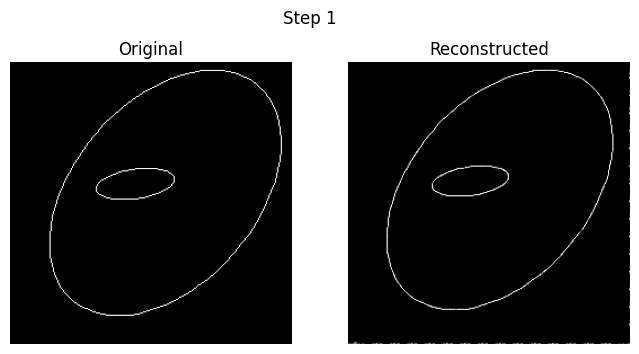

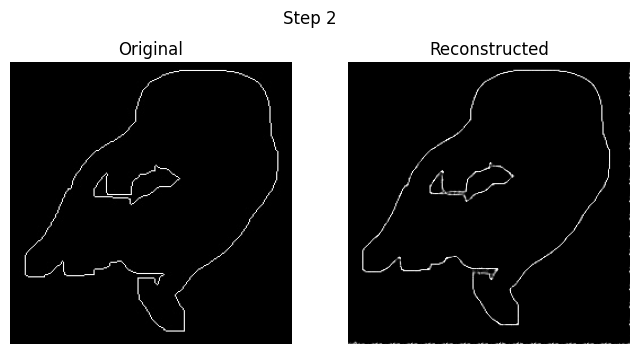

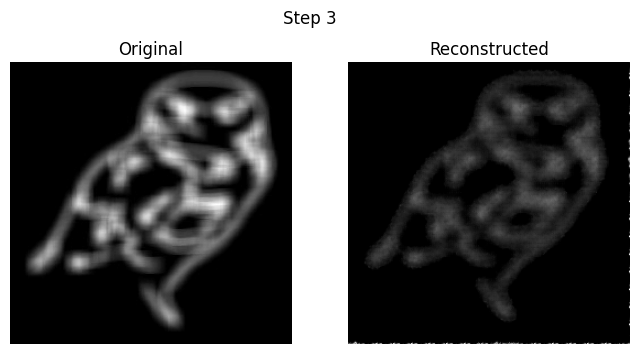

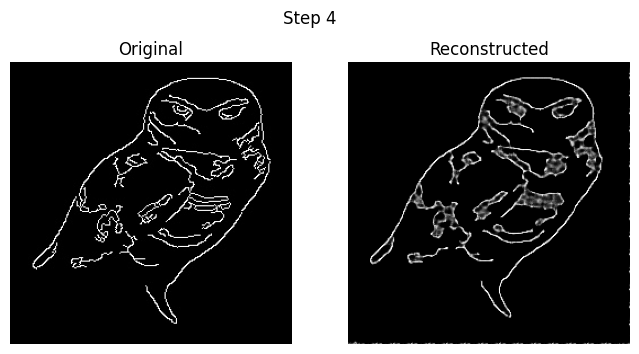

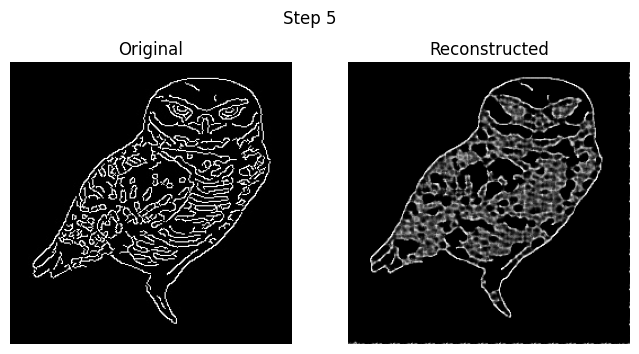

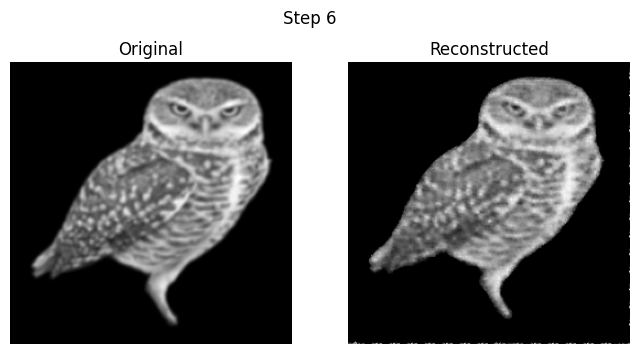

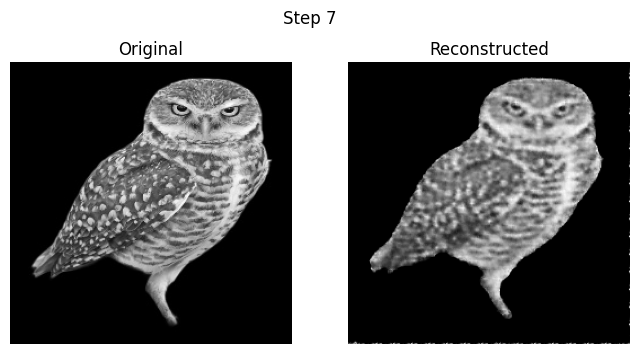

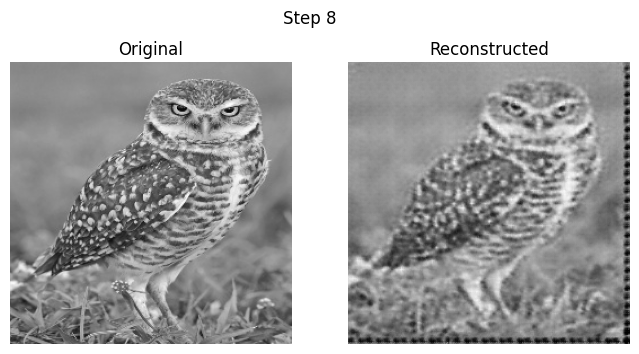

In [4]:
n_img = 80
for i in range(8):
    img = cv2.imread(f"train_step/images/owl_{n_img}_step_{(i+1)}.jpg",cv2.IMREAD_GRAYSCALE)
    # Normalize to [0,1]
    img = img.astype(np.float32) / 255.0
    # Convert to tensor: (1,1,250,250)
    img_tensor = torch.from_numpy(img).unsqueeze(0).unsqueeze(0).to(device)
    # --- 3. Encode ---
    with torch.no_grad():
        latent = model.encoder(img_tensor)
    # print("Latent shape:", latent.shape)
    # --- 4. Decode ---
    with torch.no_grad():
        recon = model.decoder(latent)
    # --- 5. Convert back to image ---
    recon_img = recon.squeeze().cpu().numpy()
    # Clip values (important)
    #recon_img = np.clip(recon_img, 0, 1)
    # --- 6. Plot ---
    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.title("Original")
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.subplot(1,2,2)
    plt.title("Reconstructed")
    plt.imshow(recon_img, cmap="gray")
    plt.axis("off")
    plt.suptitle(f"Step {(i+1)}")
    plt.show()

In [8]:

# ----------------------------
# CONFIG
# ----------------------------
folder = "train_step/images/"

pattern = r"owl_(\d+)_step_(\d+)"


# ----------------------------
# PARSE FILES
# ----------------------------
data = {}

for f in os.listdir(folder):
    match = re.match(pattern, f)
    if match:
        img_id = int(match.group(1))
        step = int(match.group(2))

        if img_id not in data:
            data[img_id] = {}

        data[img_id][step] = os.path.join(folder, f)

# ----------------------------
# PREPROCESS + ENCODE
# ----------------------------
def preprocess(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (250, 250))
    img = img.astype(np.float32) / 255.0
    img = torch.from_numpy(img).unsqueeze(0).unsqueeze(0)
    return img.to(device)

def encode(x):
    with torch.no_grad():
        z = model.encoder(x)
        return z.view(z.size(0), -1)  # flatten

# ----------------------------
# BUILD TRAJECTORIES
# ----------------------------
trajectories = {}

for img_id, steps in data.items():
    traj = []

    for step in range(1,9):
        if step in steps:
            x = preprocess(steps[step])
            z = encode(x).squeeze(0)
            traj.append(z)

    if len(traj) > 1:
        trajectories[img_id] = torch.stack(traj)

# ----------------------------
# CROSS-STEP SIMILARITY
# ----------------------------


step_sims = np.zeros((8, 8))
counts = np.zeros((8, 8))

for step_i in range(8):
    for step_j in range(8):

        vec_i = []
        vec_j = []
        ids = []

        # collect aligned pairs (same image index order)
        for img_id, steps in trajectories.items():
            if step_i < steps.shape[0] and step_j < steps.shape[0]:
                vec_i.append(steps[step_i])
                vec_j.append(steps[step_j])
                ids.append(img_id)

        if len(vec_i) < 2:
            continue

        X_i = F.normalize(torch.stack(vec_i), dim=1)
        X_j = F.normalize(torch.stack(vec_j), dim=1)

        sim = X_i @ X_j.T  # cross similarity
        sim = sim.cpu().numpy()

        # exclude SAME image pairs
        for a in range(len(ids)):
            for b in range(len(ids)):
                if ids[a] != ids[b]:   # <-- key condition
                    step_sims[step_i, step_j] += sim[a, b]
                    counts[step_i, step_j] += 1

avg_sim = step_sims / np.maximum(counts, 1)
data

{60: {7: 'train_step/images/owl_60_step_7.jpg',
  2: 'train_step/images/owl_60_step_2.jpg',
  1: 'train_step/images/owl_60_step_1.jpg',
  4: 'train_step/images/owl_60_step_4.jpg',
  6: 'train_step/images/owl_60_step_6.jpg',
  8: 'train_step/images/owl_60_step_8.jpg',
  5: 'train_step/images/owl_60_step_5.jpg',
  3: 'train_step/images/owl_60_step_3.jpg'},
 13: {3: 'train_step/images/owl_13_step_3.jpg',
  8: 'train_step/images/owl_13_step_8.jpg',
  6: 'train_step/images/owl_13_step_6.jpg',
  1: 'train_step/images/owl_13_step_1.jpg',
  2: 'train_step/images/owl_13_step_2.jpg',
  7: 'train_step/images/owl_13_step_7.jpg',
  4: 'train_step/images/owl_13_step_4.jpg',
  5: 'train_step/images/owl_13_step_5.jpg'},
 18: {4: 'train_step/images/owl_18_step_4.jpg',
  5: 'train_step/images/owl_18_step_5.jpg',
  1: 'train_step/images/owl_18_step_1.jpg',
  8: 'train_step/images/owl_18_step_8.jpg',
  7: 'train_step/images/owl_18_step_7.jpg',
  3: 'train_step/images/owl_18_step_3.jpg',
  6: 'train_step/i

In [6]:
trajectories[60].size()

torch.Size([8, 32768])

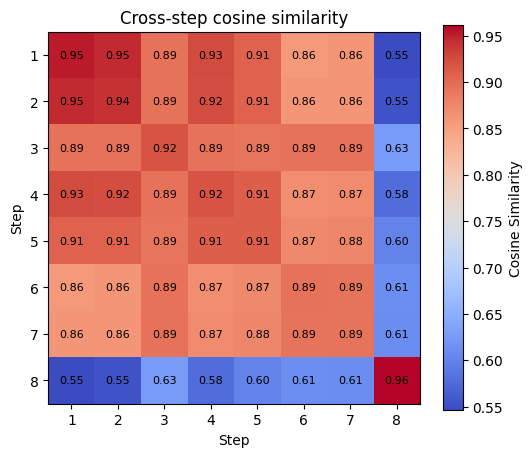

In [9]:
# ----------------------------
# PLOT HEATMAP
# ----------------------------
plt.figure(figsize=(6, 5))

plt.imshow(avg_sim, cmap="coolwarm")#, vmin=0, vmax=1)

plt.colorbar(label="Cosine Similarity")

plt.xticks(range(8), range(1, 9))
plt.yticks(range(8), range(1, 9))

plt.xlabel("Step")
plt.ylabel("Step")
plt.title("Cross-step cosine similarity")

# annotate values
for i in range(8):
    for j in range(8):
        plt.text(j, i, f"{avg_sim[i, j]:.2f}",
                 ha="center", va="center", color="black", fontsize=8)

plt.show()